# 01 – Data Audit

Dieses Notebook ist die erste Prüf- und Freigabestufe des Projekts.

Es untersucht ausschließlich die technische und fachliche Verlässlichkeit des
kanonischen BTCUSDT-15-Minuten-Datensatzes:

- Schema und Datentypen
- Nullwerte und unendliche Werte
- Duplikate und widersprüchliche Schlüssel
- OHLC-Invarianten
- Zeitraster und Kerzenschluss
- Datenlücken und Vollständigkeit
- Quellen- und Zeitraumabdeckung
- problematische Einzelzeilen

Das Notebook verändert keine Daten. Die vollständige fachliche EDA wird erst in
`02_eda.ipynb` durchgeführt.

Benötigte Pakete:

```bash
pip install pandas numpy matplotlib pyarrow
```

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

from IPython import get_ipython
from IPython.display import Markdown, display

_ipython = get_ipython()
if _ipython is not None:
    _ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

search_locations = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (
        path
        for path in search_locations
        if (path / "eda.py").exists()
        and (path / "data_quality.py").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Projektwurzel nicht gefunden. Starte das Notebook im Projekt "
        "oder in einem Unterordner mit eda.py und data_quality.py."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from config import SETTINGS
except ImportError:
    from config_complete import SETTINGS

from data_quality import DataQualityValidator
from eda import (
    analyze_duplicates,
    analyze_missingness,
    analyze_time_coverage,
    create_dataset_overview,
    load_canonical_data,
)

print(f"Projektwurzel: {PROJECT_ROOT}")
print(f"Matplotlib-Backend: {plt.get_backend()}")
print(f"Symbol / Intervall: {SETTINGS.market.symbol} / {SETTINGS.market.interval}")

Projektwurzel: /home/milan/uni/python/BTC TSP/BTC TSP 15min
Matplotlib-Backend: inline
Symbol / Intervall: BTCUSDT / 15m


## 1. Parameter

Der Data Audit prüft immer den vollständigen lokal vorhandenen Datensatz bis zur
neuesten abgeschlossenen Kerze. Der reservierte Testzeitraum wird hier nicht
ausgeschlossen, weil auch er technisch korrekt und vollständig sein muss.

In [2]:
DATA_PATH: Path | None = None
MAXIMUM_ISSUE_EXAMPLES = 25
MAXIMUM_DISPLAY_ROWS = 30

print("Alternativer Datenpfad:", DATA_PATH)

Alternativer Datenpfad: None


## 2. Kanonischen Datensatz laden

In [3]:
raw_df = load_canonical_data(SETTINGS, data_path=DATA_PATH)

print(f"Geladene Zeilen: {len(raw_df):,}")
print(f"Geladene Spalten: {len(raw_df.columns)}")
print(f"Quelldatei: {raw_df.attrs.get('source_path')}")
display(raw_df.head(3))
display(raw_df.tail(3))

Geladene Zeilen: 230,618
Geladene Spalten: 15
Quelldatei: /home/milan/uni/python/BTC TSP/BTC TSP 15min/data/processed/candles/BTCUSDT_15m_candles.parquet


,symbol,interval,open_time,close_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,source,ingested_at
0,BTCUSDT,15m,2020-01-01 00:00:00+00:00,2020-01-01 00:14:59.999000+00:00,"7,195.240000","7,196.250000","7,178.200000","7,180.970000",202.942868,"1,458,244.899635",2452,76.962041,"553,069.534929",binance_vision,2026-07-31 20:30:33.718440+00:00
1,BTCUSDT,15m,2020-01-01 00:15:00+00:00,2020-01-01 00:29:59.999000+00:00,"7,180.970000","7,186.400000","7,175.470000","7,178.450000",128.242654,"920,702.747079",1948,58.389110,"419,226.471447",binance_vision,2026-07-31 20:30:33.718440+00:00
2,BTCUSDT,15m,2020-01-01 00:30:00+00:00,2020-01-01 00:44:59.999000+00:00,"7,178.190000","7,185.440000","7,176.230000","7,179.560000",83.487458,"599,479.152805",1580,43.822374,"314,667.321072",binance_vision,2026-07-31 20:30:33.718440+00:00


,symbol,interval,open_time,close_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,source,ingested_at
230615,BTCUSDT,15m,2026-07-31 19:45:00+00:00,2026-07-31 19:59:59.999000+00:00,"63,000.450000","63,052.000000","62,954.030000","62,972.000000",121.767940,"7,671,430.630851",20362,67.756190,"4,268,741.409264",binance_rest,2026-07-31 20:30:45.399797+00:00
230616,BTCUSDT,15m,2026-07-31 20:00:00+00:00,2026-07-31 20:14:59.999000+00:00,"62,972.000000","63,005.470000","62,944.840000","62,999.340000",66.739300,"4,203,093.101967",16377,36.884490,"2,322,813.849803",binance_rest,2026-07-31 20:30:45.399797+00:00
230617,BTCUSDT,15m,2026-07-31 20:15:00+00:00,2026-07-31 20:29:59.999000+00:00,"62,999.330000","63,034.000000","62,982.000000","63,005.520000",55.162400,"3,475,712.997280",9537,33.023940,"2,080,669.741292",binance_rest,2026-07-31 20:30:45.399797+00:00


## 3. Vollständiges Qualitätsgate

In [4]:
validator = DataQualityValidator(
    SETTINGS,
    maximum_examples=MAXIMUM_ISSUE_EXAMPLES,
)
quality_report = validator.validate(raw_df)

audit_summary = pd.DataFrame(
    [
        {
            "status": quality_report.status,
            "is_valid": quality_report.is_valid,
            "rows": quality_report.row_count,
            "columns": quality_report.column_count,
            "first_open_time": quality_report.first_open_time,
            "last_open_time": quality_report.last_open_time,
            "errors": len(quality_report.errors),
            "warnings": len(quality_report.warnings),
            "issue_count": quality_report.issue_count,
            "invalid_rows": quality_report.invalid_row_count,
        }
    ]
)

display(audit_summary)

if quality_report.errors:
    display(Markdown("### Kritische Fehler"))
    display(pd.DataFrame({"error": quality_report.errors}))

if quality_report.warnings:
    display(Markdown("### Warnungen"))
    display(pd.DataFrame({"warning": quality_report.warnings}))

,status,is_valid,rows,columns,first_open_time,last_open_time,errors,warnings,issue_count,invalid_rows
0,warning,True,230618,15,2020-01-01T00:00:00+00:00,2026-07-31T20:15:00+00:00,0,7,7,0


### Warnungen

,warning
0,13 Zeile(n) enthalten ein Volumen von 0.
1,13 Zeile(n) enthalten 0 Trades.
2,1 Zeile(n) haben eine logisch ungültige Bezieh...
3,6 Zeile(n) enden mehr als 5 Sekunden vor dem e...
4,152 Kerze(n) fehlen; größte Lücke: 23 Kerze(n).
5,1 Rendite(n) überschreiten den Warnschwellenwe...
6,4310 Volumenwert(e) überschreiten den robusten...


## 4. Issue-Codes und betroffene Zeilen

In [5]:
issues_df = pd.DataFrame(quality_report.issues)

if issues_df.empty:
    display(Markdown("**Keine Qualitäts-Issues vorhanden.**"))
else:
    preferred_columns = [
        "code",
        "severity",
        "message",
        "affected_rows",
        "column",
    ]
    existing_columns = [
        column for column in preferred_columns if column in issues_df.columns
    ]
    display(
        issues_df[existing_columns]
        .sort_values(["severity", "affected_rows"], ascending=[True, False])
        .reset_index(drop=True)
    )

,code,severity,message,affected_rows,column
0,plausibility.extreme_volume,warning,4310 Volumenwert(e) überschreiten den robusten...,4310,None
1,completeness.time_gaps,warning,152 Kerze(n) fehlen; größte Lücke: 23 Kerze(n).,152,None
2,plausibility.zero_volume,warning,13 Zeile(n) enthalten ein Volumen von 0.,13,None
3,plausibility.zero_trades,warning,13 Zeile(n) enthalten 0 Trades.,13,None
4,temporal.nonstandard_close_time,warning,6 Zeile(n) enden mehr als 5 Sekunden vor dem e...,6,None
5,temporal.invalid_close_time,warning,1 Zeile(n) haben eine logisch ungültige Bezieh...,1,None
6,plausibility.extreme_return,warning,1 Rendite(n) überschreiten den Warnschwellenwe...,1,None


## 5. Schema, Spalten und Datentypen

In [6]:
schema_table = pd.DataFrame(
    {
        "column": raw_df.columns,
        "dtype": [str(raw_df[column].dtype) for column in raw_df.columns],
        "missing_count": [
            int(raw_df[column].isna().sum()) for column in raw_df.columns
        ],
        "unique_values": [
            int(raw_df[column].nunique(dropna=True)) for column in raw_df.columns
        ],
    }
)

display(schema_table)

display(
    pd.DataFrame(
        {
            "missing_columns": pd.Series(quality_report.missing_columns),
            "unexpected_columns": pd.Series(quality_report.unexpected_columns),
        }
    )
)

if quality_report.dtype_issues:
    display(
        pd.DataFrame(
            quality_report.dtype_issues.items(),
            columns=["column", "dtype_issue"],
        )
    )

,column,dtype,missing_count,unique_values
0,symbol,str,0,1
1,interval,str,0,1
2,open_time,"datetime64[us, UTC]",0,230618
3,close_time,"datetime64[us, UTC]",0,230618
4,open,float64,0,221134
5,high,float64,0,204357
6,low,float64,0,206869
7,close,float64,0,220994
8,volume,float64,0,230403
9,quote_asset_volume,float64,0,230606


,missing_columns,unexpected_columns


## 6. Datensatzsteckbrief und zeitliche Abdeckung

In [7]:
overview = create_dataset_overview(raw_df, SETTINGS)

display(
    pd.DataFrame(
        [
            {
                "Zeilen": overview["row_count"],
                "Eindeutige Kerzen": overview["unique_candle_count"],
                "Spalten": overview["column_count"],
                "Beginn": overview["first_open_time"],
                "Ende": overview["last_open_time"],
                "Kalendertage": overview["observed_calendar_days"],
                "Speicher in MiB": overview["memory_megabytes"],
            }
        ]
    )
)

display(Markdown("### Quellen"))
display(
    pd.DataFrame(
        overview["source_counts"].items(),
        columns=["source", "rows"],
    )
)

display(Markdown("### Kerzen pro Jahr"))
display(
    pd.DataFrame(
        overview["rows_by_year"].items(),
        columns=["year", "rows"],
    )
)

,Zeilen,Eindeutige Kerzen,Spalten,Beginn,Ende,Kalendertage,Speicher in MiB
0,230618,230618,15,2020-01-01T00:00:00+00:00,2026-07-31T20:15:00+00:00,2404,31.875647


### Quellen

,source,rows
0,binance_vision,227656
1,existing,2445
2,binance_rest,517


### Kerzen pro Jahr

,year,rows
0,2020,35054
1,2021,34975
2,2022,35040
3,2023,35035
4,2024,35136
5,2025,35040
6,2026,20338


## 7. Missingness

,total_missing_values,columns_with_missing_values
0,0,0


### `missingness`

,column,missing_count,missing_ratio,dtype
0,close,0,0.000000,float64
1,close_time,0,0.000000,"datetime64[us, UTC]"
2,high,0,0.000000,float64
3,ingested_at,0,0.000000,"datetime64[us, UTC]"
4,interval,0,0.000000,str
5,low,0,0.000000,float64
6,number_of_trades,0,0.000000,Int64
7,open,0,0.000000,float64
8,open_time,0,0.000000,"datetime64[us, UTC]"
9,quote_asset_volume,0,0.000000,float64


### `missingness_by_year`

""


### `missingness_by_source`

""


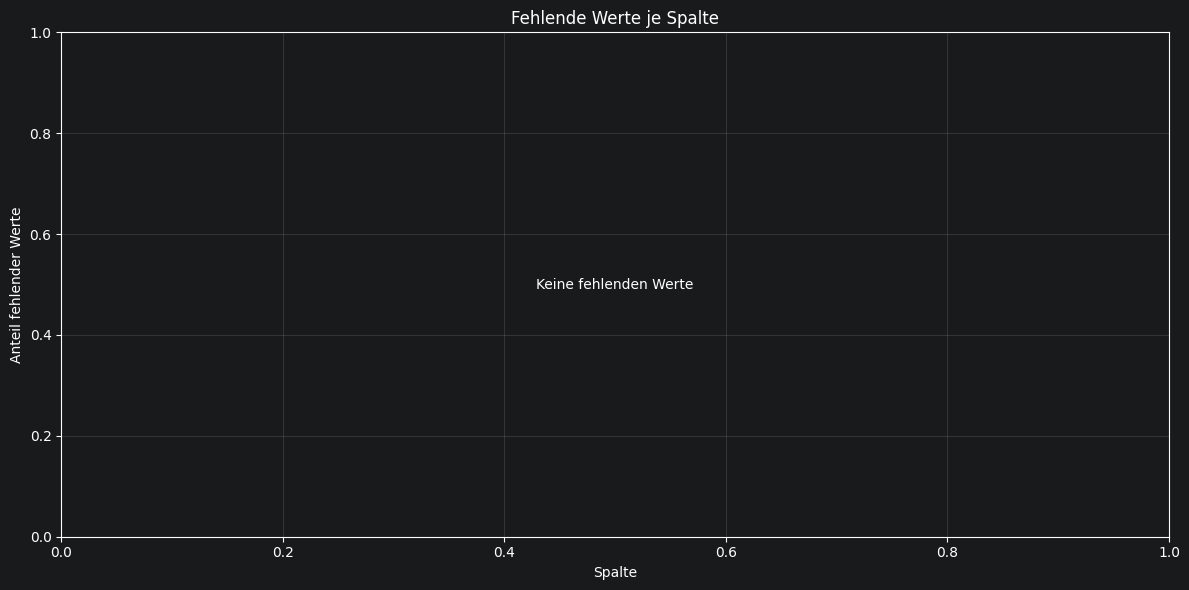

In [8]:
missing_bundle = analyze_missingness(raw_df)

display(pd.DataFrame([missing_bundle.summary]))

for name in ("missingness", "missingness_by_year", "missingness_by_source"):
    table = missing_bundle.tables.get(name)
    if table is not None:
        display(Markdown(f"### `{name}`"))
        display(table.head(MAXIMUM_DISPLAY_ROWS))

for figure in missing_bundle.figures.values():
    display(figure)
    plt.close(figure)

## 8. Duplikate und Quellenkonflikte

In [9]:
duplicate_bundle = analyze_duplicates(raw_df, SETTINGS)

display(pd.DataFrame([duplicate_bundle.summary]))

for name in (
    "duplicate_summary",
    "conflicting_duplicates",
    "duplicate_keys",
    "exact_duplicates",
):
    table = duplicate_bundle.tables.get(name)
    if table is not None:
        display(Markdown(f"### `{name}`"))
        display(table.head(MAXIMUM_DISPLAY_ROWS))

,exact_duplicate_rows,duplicate_key_rows,conflicting_duplicate_keys
0,0,0,0


### `duplicate_summary`

,type,count
0,exact_duplicate_rows,0
1,duplicate_key_rows,0
2,conflicting_duplicate_keys,0


### `conflicting_duplicates`

""


### `duplicate_keys`

,symbol,interval,open_time,close_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,source,ingested_at


### `exact_duplicates`

,symbol,interval,open_time,close_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,source,ingested_at


## 9. Zeitraster, Lücken und Vollständigkeit

,expected_candles_per_full_day,observed_unique_candles,missing_candles,gap_blocks,largest_gap_candles,completeness_ratio_observed_range,incomplete_days
0,96,230618,152,15,23,0.999341,16


### `daily_coverage`

,date,actual_candles,expected_candles,missing_candles,completeness_ratio
0,2020-01-01 00:00:00+00:00,96,96,0,1.000000
1,2020-01-02 00:00:00+00:00,96,96,0,1.000000
2,2020-01-03 00:00:00+00:00,96,96,0,1.000000
3,2020-01-04 00:00:00+00:00,96,96,0,1.000000
4,2020-01-05 00:00:00+00:00,96,96,0,1.000000
5,2020-01-06 00:00:00+00:00,96,96,0,1.000000
6,2020-01-07 00:00:00+00:00,96,96,0,1.000000
7,2020-01-08 00:00:00+00:00,96,96,0,1.000000
8,2020-01-09 00:00:00+00:00,96,96,0,1.000000
9,2020-01-10 00:00:00+00:00,96,96,0,1.000000


### `monthly_coverage`

,month,actual_candles
0,2020-01,2976
1,2020-02,2757
2,2020-03,2968
3,2020-04,2870
4,2020-05,2976
5,2020-06,2866
6,2020-07,2976
7,2020-08,2976
8,2020-09,2880
9,2020-10,2976


### `gaps`

,after,before,missing_candles,gap_duration,symbol,interval
0,2020-02-09T01:45:00+00:00,2020-02-09T03:00:00+00:00,4,0 days 01:15:00,BTCUSDT,15m
1,2020-02-19T11:30:00+00:00,2020-02-19T17:30:00+00:00,23,0 days 06:00:00,BTCUSDT,15m
2,2020-03-04T09:15:00+00:00,2020-03-04T11:30:00+00:00,8,0 days 02:15:00,BTCUSDT,15m
3,2020-04-25T01:45:00+00:00,2020-04-25T04:30:00+00:00,10,0 days 02:45:00,BTCUSDT,15m
4,2020-06-28T01:45:00+00:00,2020-06-28T05:30:00+00:00,14,0 days 03:45:00,BTCUSDT,15m
5,2020-11-30T05:45:00+00:00,2020-11-30T07:00:00+00:00,4,0 days 01:15:00,BTCUSDT,15m
6,2020-12-21T14:00:00+00:00,2020-12-21T18:00:00+00:00,15,0 days 04:00:00,BTCUSDT,15m
7,2020-12-25T01:45:00+00:00,2020-12-25T03:00:00+00:00,4,0 days 01:15:00,BTCUSDT,15m
8,2021-02-11T03:30:00+00:00,2021-02-11T05:00:00+00:00,5,0 days 01:30:00,BTCUSDT,15m
9,2021-03-06T01:45:00+00:00,2021-03-06T03:30:00+00:00,6,0 days 01:45:00,BTCUSDT,15m


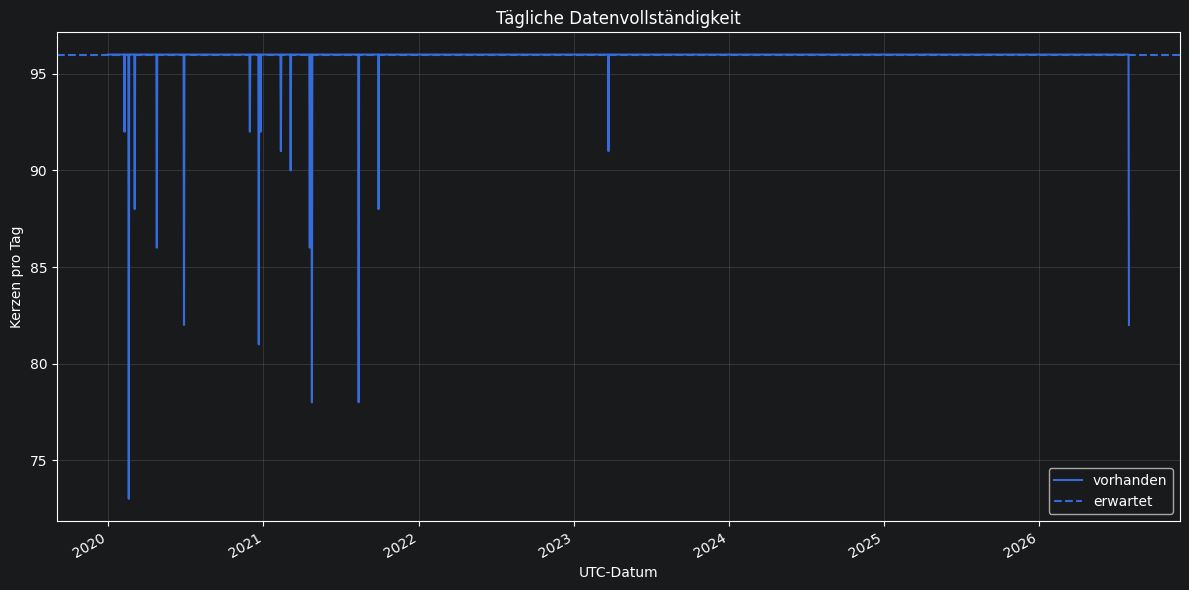

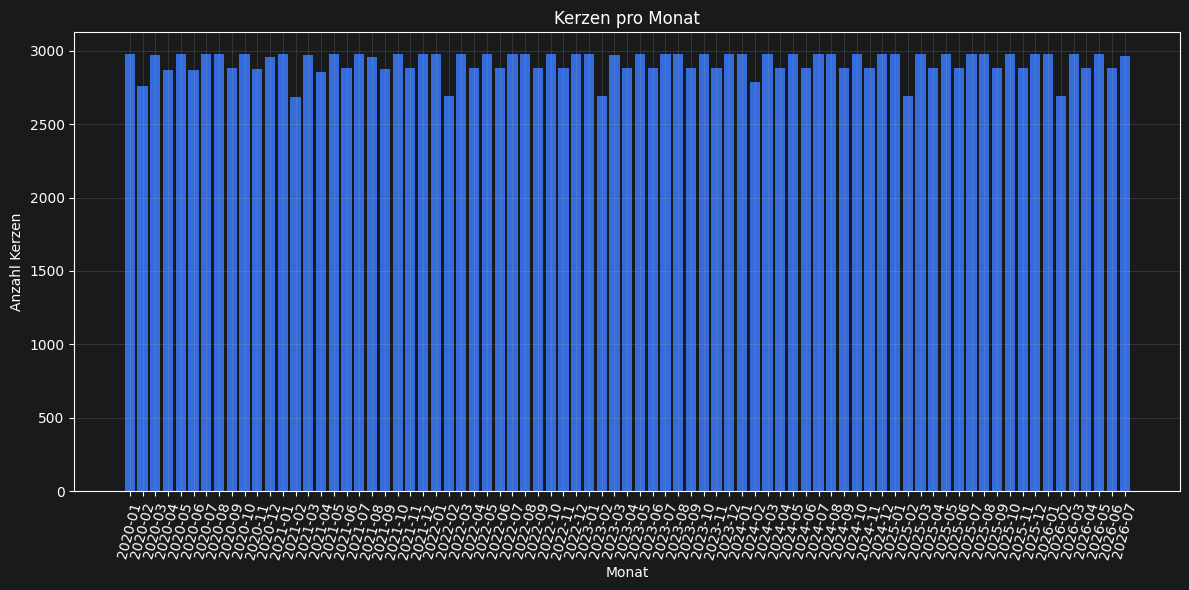

In [10]:
coverage_bundle = analyze_time_coverage(raw_df, SETTINGS)

display(pd.DataFrame([coverage_bundle.summary]))

for name in ("daily_coverage", "monthly_coverage", "gaps"):
    table = coverage_bundle.tables.get(name)
    if table is not None:
        display(Markdown(f"### `{name}`"))
        display(table.head(MAXIMUM_DISPLAY_ROWS))

for figure in coverage_bundle.figures.values():
    display(figure)
    plt.close(figure)

## 10. Fachliche Kernprüfungen

In [11]:
core_checks = pd.DataFrame(
    [
        {
            "check": "duplicate_keys",
            "affected_rows": quality_report.duplicate_keys,
        },
        {
            "check": "conflicting_duplicate_keys",
            "affected_rows": quality_report.conflicting_duplicate_keys,
        },
        {
            "check": "invalid_ohlc_rows",
            "affected_rows": quality_report.invalid_ohlc_rows,
        },
        {
            "check": "non_positive_price_rows",
            "affected_rows": quality_report.non_positive_price_rows,
        },
        {
            "check": "negative_volume_rows",
            "affected_rows": quality_report.negative_volume_rows,
        },
        {
            "check": "negative_trade_count_rows",
            "affected_rows": quality_report.negative_trade_count_rows,
        },
        {
            "check": "invalid_close_time_rows",
            "affected_rows": quality_report.invalid_close_time_rows,
        },
        {
            "check": "off_grid_rows",
            "affected_rows": quality_report.off_grid_rows,
        },
        {
            "check": "open_or_future_candle_rows",
            "affected_rows": quality_report.open_or_future_candle_rows,
        },
        {
            "check": "missing_interval_count",
            "affected_rows": quality_report.missing_interval_count,
        },
    ]
)

display(core_checks)

,check,affected_rows
0,duplicate_keys,0
1,conflicting_duplicate_keys,0
2,invalid_ohlc_rows,0
3,non_positive_price_rows,0
4,negative_volume_rows,0
5,negative_trade_count_rows,0
6,invalid_close_time_rows,1
7,off_grid_rows,0
8,open_or_future_candle_rows,0
9,missing_interval_count,152


## 11. Problematische Einzelzeilen

In [12]:
invalid_rows = validator.invalid_rows(raw_df)

if invalid_rows.empty:
    display(Markdown("**Keine zeilenbezogenen Qualitätsfehler gefunden.**"))
else:
    print(f"Problematische Zeilen: {len(invalid_rows):,}")
    display(invalid_rows.head(MAXIMUM_DISPLAY_ROWS))

Problematische Zeilen: 7


,symbol,interval,open_time,close_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,source,ingested_at,quality_reasons
4746,BTCUSDT,15m,2020-02-19 11:30:00+00:00,2020-02-19 11:35:32.286000+00:00,"10,133.120000","10,150.000000","10,133.100000","10,148.930000",42.048618,"426,533.899734",534,33.260631,"337,428.201249",binance_vision,2026-07-31 20:30:33.887932+00:00,nonstandard_close_time
6058,BTCUSDT,15m,2020-03-04 09:15:00+00:00,2020-03-04 09:21:46.694000+00:00,"8,805.720000","8,810.950000","8,791.060000","8,795.060000",35.066062,"308,773.051427",462,14.853535,"130,811.555052",binance_vision,2026-07-31 20:30:34.023114+00:00,nonstandard_close_time
34073,BTCUSDT,15m,2020-12-21 14:00:00+00:00,2020-12-21 13:47:20.521000+00:00,"22,646.530000","22,646.530000","22,646.530000","22,646.530000",0.000000,0.000000,0,0.000000,0.000000,binance_vision,2026-07-31 20:30:35.216137+00:00,invalid_close_time
39004,BTCUSDT,15m,2021-02-11 03:30:00+00:00,2021-02-11 03:40:54.773000+00:00,"44,582.070000","44,582.070000","44,582.070000","44,582.070000",0.000000,0.000000,0,0.000000,0.000000,binance_vision,2026-07-31 20:30:35.454534+00:00,nonstandard_close_time
45993,BTCUSDT,15m,2021-04-25 04:00:00+00:00,2021-04-25 04:00:58.146000+00:00,"49,626.760000","49,705.040000","49,600.240000","49,683.940000",5.887034,"292,226.013457",224,4.229245,"209,956.010474",binance_vision,2026-07-31 20:30:35.696481+00:00,nonstandard_close_time
69280,BTCUSDT,15m,2021-12-24 04:45:00+00:00,2021-12-24 04:59:54.362000+00:00,"51,067.970000","51,109.090000","50,926.550000","50,951.470000",80.098020,"4,084,643.206405",4778,41.940150,"2,139,803.535788",binance_vision,2026-07-31 20:30:36.704845+00:00,nonstandard_close_time
112991,BTCUSDT,15m,2023-03-24 12:30:00+00:00,2023-03-24 12:39:41.646000+00:00,"28,080.000000","28,080.000000","28,080.000000","28,080.000000",0.000000,0.000000,0,0.000000,0.000000,binance_vision,2026-07-31 20:30:38.780339+00:00,nonstandard_close_time


## 12. Audit-Bericht optional speichern

In [13]:
SAVE_AUDIT_ARTIFACTS = False

if SAVE_AUDIT_ARTIFACTS:
    run_id = pd.Timestamp.now(tz="UTC").strftime("%Y%m%dT%H%M%S%fZ")
    audit_dir = Path(SETTINGS.paths.reports_dir) / "data_audit" / run_id
    audit_dir.mkdir(parents=True, exist_ok=True)

    report_path = validator.save_report(
        quality_report,
        run_id=run_id,
        output_path=audit_dir / "quality_report.json",
    )
    invalid_path = validator.save_invalid_rows(
        raw_df,
        run_id=run_id,
        output_path=audit_dir / "invalid_rows.csv",
    )

    print("Audit-Verzeichnis:", audit_dir)
    print("Quality Report:", report_path)
    print("Invalid Rows:", invalid_path)
else:
    print("Keine Audit-Artefakte gespeichert.")

Keine Audit-Artefakte gespeichert.


## 13. Freigabeentscheidung

In [14]:
if quality_report.is_valid:
    display(
        Markdown(
            "## ✅ Data Audit bestanden\n\n"
            "Der Datensatz kann in `02_eda.ipynb` fachlich analysiert werden. "
            "Vorhandene Warnungen müssen dort sichtbar berücksichtigt werden."
        )
    )
else:
    display(
        Markdown(
            "## ❌ Data Audit nicht bestanden\n\n"
            "Die Fehler sollten in Datenpipeline oder Qualitätslogik behoben "
            "werden, bevor die fachliche EDA durchgeführt wird."
        )
    )

## ✅ Data Audit bestanden

Der Datensatz kann in `02_eda.ipynb` fachlich analysiert werden. Vorhandene Warnungen müssen dort sichtbar berücksichtigt werden.